# EuroSAT Land Cover Classification - Training Notebook

Complete training pipeline for land cover classification using EuroSAT RGB dataset with PyTorch and GPU acceleration.

## Step 1: Check GPU Availability

In [2]:
import torch

# Check GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

if torch.cuda.is_available():
    print(f'GPU Name: {torch.cuda.get_device_name(0)}')
    print(f'GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB')
else:
    print('WARNING: GPU not available! Training will be slow on CPU.')
    print('Go to Runtime > Change runtime type > Hardware accelerator: GPU')

Using device: cuda
GPU Name: Tesla T4
GPU Memory: 14.74 GB


## Step 2: Import Required Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

print("All libraries imported successfully!")

All libraries imported successfully!


## Step 3: Configure Paths and Load Data

In [4]:
# Configure paths (update these if your files are in different locations)
ROOT_PATH = '/content'
BASE_PATH = os.path.join(ROOT_PATH, 'EuroSAT_RGB')
CSV_FILE = os.path.join(ROOT_PATH, 'eurosat_rgb_data.csv')

# Load the CSV file
df = pd.read_csv(CSV_FILE)
print(f"✓ Total images loaded: {len(df)}")
print(f"✓ Columns: {df.columns.tolist()}")
print(f"\n{'='*60}")
print("Class Distribution:")
print(df['label'].value_counts().sort_index())
print(f"{'='*60}")
print(f"\nNumber of classes: {df['label'].nunique()}")

✓ Total images loaded: 54000
✓ Columns: ['image_path', 'label']

Class Distribution:
label
AnnualCrop              6000
Forest                  6000
HerbaceousVegetation    6000
Highway                 5000
Industrial              5000
Pasture                 4000
PermanentCrop           5000
Residential             6000
River                   5000
SeaLake                 6000
Name: count, dtype: int64

Number of classes: 10


## Step 4: Create Custom Dataset Class

In [5]:
class EuroSATDataset(Dataset):
    def __init__(self, dataframe, base_path, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.base_path = base_path
        self.transform = transform

        # Encode labels to numerical values
        self.le = LabelEncoder()
        self.df['encoded_label'] = self.le.fit_transform(self.df['label'])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Get image path and label
        relative_path = row['image_path'].replace('\\', '/')
        img_path = os.path.join(self.base_path, relative_path)
        label = row['encoded_label']

        # Load and convert image to RGB
        image = Image.open(img_path).convert('RGB')

        # Apply transformations
        if self.transform:
            image = self.transform(image)

        return image, label

    def get_classes(self):
        return self.le.classes_

print("✓ Custom Dataset class created!")

✓ Custom Dataset class created!


## Step 5: Define Data Augmentation and Preprocessing

In [6]:
# Training transforms with data augmentation
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Validation transforms (no augmentation)
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

print("✓ Data transforms configured!")

✓ Data transforms configured!


## Step 6: Split Data and Create DataLoaders

In [7]:
# Split data into train and validation sets (80/20 split)
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

print(f"Training samples: {len(train_df)}")
print(f"Validation samples: {len(val_df)}")

# Create dataset instances
train_dataset = EuroSATDataset(train_df, BASE_PATH, transform=train_transform)
val_dataset = EuroSATDataset(val_df, BASE_PATH, transform=val_transform)

# Create data loaders
BATCH_SIZE = 64
NUM_WORKERS = 2

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

# Get number of classes and class names
num_classes = len(df['label'].unique())
class_names = sorted(df['label'].unique())

print(f"\n✓ DataLoaders created!")
print(f"✓ Number of classes: {num_classes}")
print(f"✓ Batch size: {BATCH_SIZE}")
print(f"✓ Training batches: {len(train_loader)}")
print(f"✓ Validation batches: {len(val_loader)}")

Training samples: 43200
Validation samples: 10800

✓ DataLoaders created!
✓ Number of classes: 10
✓ Batch size: 64
✓ Training batches: 675
✓ Validation batches: 169


## Step 7: Build Model with Transfer Learning

In [8]:
# Load pre-trained Wide ResNet-50-2 model
model = models.wide_resnet50_2(pretrained=True)

# Replace the final fully connected layer for our number of classes
model.fc = nn.Linear(model.fc.in_features, num_classes)

# Move model to GPU
model = model.to(device)

print(f"✓ Model created and moved to {device}")
print(f"✓ Model type: Wide ResNet-50-2 (Transfer Learning)")
print(f"✓ Output classes: {num_classes}")
print(f"✓ Total parameters: {sum(p.numel() for p in model.parameters()):,}")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Wide_ResNet50_2_Weights.IMAGENET1K_V1`. You can also use `weights=Wide_ResNet50_2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/wide_resnet50_2-95faca4d.pth" to /root/.cache/torch/hub/checkpoints/wide_resnet50_2-95faca4d.pth


100%|██████████| 132M/132M [00:00<00:00, 168MB/s]


✓ Model created and moved to cuda
✓ Model type: Wide ResNet-50-2 (Transfer Learning)
✓ Output classes: 10
✓ Total parameters: 66,854,730


## Step 8: Define Loss Function, Optimizer, and Scheduler

In [9]:
# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    patience=3,
    factor=0.5
)

print("✓ Loss function: CrossEntropyLoss")
print("✓ Optimizer: Adam (lr=0.001)")
print("✓ Scheduler: ReduceLROnPlateau")

✓ Loss function: CrossEntropyLoss
✓ Optimizer: Adam (lr=0.001)
✓ Scheduler: ReduceLROnPlateau


## Step 9: Define Training Function

In [10]:
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()
    running_loss = 0.0
    running_corrects = 0

    # Progress bar
    pbar = tqdm(train_loader, desc='Training', leave=False)

    for inputs, labels in pbar:
        # Move data to GPU
        inputs = inputs.to(device)
        labels = labels.to(device)

        # Zero gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        # Statistics
        _, preds = torch.max(outputs, 1)
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)

        # Update progress bar
        pbar.set_postfix({'loss': loss.item()})

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = running_corrects.double() / len(train_loader.dataset)

    return epoch_loss, epoch_acc.item()


def validate(model, val_loader, criterion, device):
    """Validate the model"""
    model.eval()
    running_loss = 0.0
    running_corrects = 0

    # Progress bar
    pbar = tqdm(val_loader, desc='Validation', leave=False)

    with torch.no_grad():
        for inputs, labels in pbar:
            # Move data to GPU
            inputs = inputs.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # Statistics
            _, preds = torch.max(outputs, 1)
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

            # Update progress bar
            pbar.set_postfix({'loss': loss.item()})

    epoch_loss = running_loss / len(val_loader.dataset)
    epoch_acc = running_corrects.double() / len(val_loader.dataset)

    return epoch_loss, epoch_acc.item()

print("✓ Training and validation functions defined!")

✓ Training and validation functions defined!


## Step 10: Train the Model

In [12]:
# Training configuration
NUM_EPOCHS = 10
BEST_MODEL_PATH = 'best_eurosat_model.pth'

# Initialize tracking variables
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}
best_val_acc = 0.0

print(f"Starting training for {NUM_EPOCHS} epochs...")
print(f"{'='*70}\n")

# Training loop
for epoch in range(NUM_EPOCHS):
    print(f"Epoch {epoch+1}/{NUM_EPOCHS}")
    print('-' * 70)

    # Train for one epoch
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )

    # Validate
    val_loss, val_acc = validate(
        model, val_loader, criterion, device
    )

    # Update learning rate
    scheduler.step(val_loss)

    # Save history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    # Print results
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f"✓ Best model saved! (Val Acc: {val_acc:.4f})")

    print()

print(f"{'='*70}")
print(f"Training completed!")
print(f"Best validation accuracy: {best_val_acc:.4f}")
print(f"Model saved to: {BEST_MODEL_PATH}")

Starting training for 10 epochs...

Epoch 1/10
----------------------------------------------------------------------


Train Loss: 0.4182 | Train Acc: 0.8664
Val Loss:   0.2909 | Val Acc:   0.8979
✓ Best model saved! (Val Acc: 0.8979)

Epoch 2/10
----------------------------------------------------------------------


Train Loss: 0.2639 | Train Acc: 0.9138
Val Loss:   0.1543 | Val Acc:   0.9469
✓ Best model saved! (Val Acc: 0.9469)

Epoch 3/10
----------------------------------------------------------------------


Train Loss: 0.2278 | Train Acc: 0.9255
Val Loss:   0.2545 | Val Acc:   0.9196

Epoch 4/10
----------------------------------------------------------------------


Train Loss: 0.2121 | Train Acc: 0.9299
Val Loss:   0.1556 | Val Acc:   0.9436

Epoch 5/10
----------------------------------------------------------------------


...

Train Loss: 0.1797 | Train Acc: 0.9401
Val Loss:   0.1291 | Val Acc:   0.9567
✓ Best model saved! (Val Acc: 0.9567)

Epoch 7/10
----------------------------------------------------------------------


Train Loss: 0.1577 | Train Acc: 0.9468
Val Loss:   0.1954 | Val Acc:   0.9321

Epoch 8/10
----------------------------------------------------------------------


Train Loss: 0.1540 | Train Acc: 0.9481
Val Loss:   0.1094 | Val Acc:   0.9640
✓ Best model saved! (Val Acc: 0.9640)

Epoch 9/10
----------------------------------------------------------------------


Train Loss: 0.1427 | Train Acc: 0.9509
Val Loss:   0.1157 | Val Acc:   0.9593

Epoch 10/10
----------------------------------------------------------------------


Train Loss: 0.1337 | Train Acc: 0.9544
Val Loss:   0.1118 | Val Acc:   0.9615

Training completed!
Best validation accuracy: 0.9640
Model saved to: best_eurosat_model.pth


## Step 11: Visualize Training Results

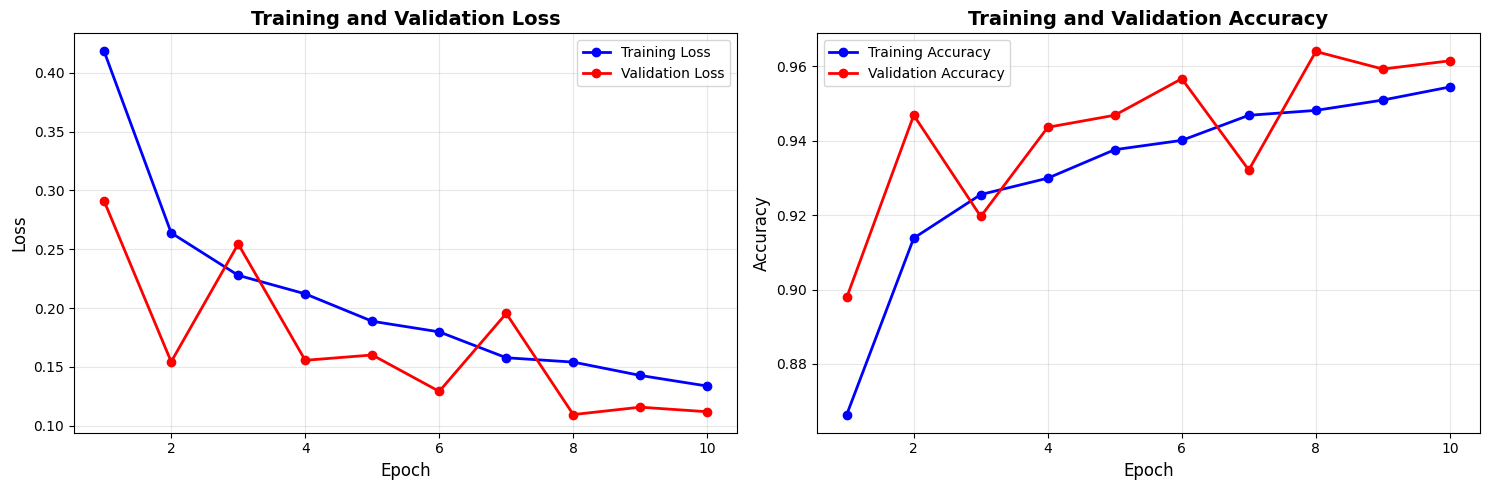

✓ Training curves saved to 'training_history.png'


In [13]:
# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot loss
epochs = range(1, len(history['train_loss']) + 1)
ax1.plot(epochs, history['train_loss'], 'b-o', label='Training Loss', linewidth=2)
ax1.plot(epochs, history['val_loss'], 'r-o', label='Validation Loss', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Plot accuracy
ax2.plot(epochs, history['train_acc'], 'b-o', label='Training Accuracy', linewidth=2)
ax2.plot(epochs, history['val_acc'], 'r-o', label='Validation Accuracy', linewidth=2)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Training curves saved to 'training_history.png'")

## Step 12: Download Trained Model

In [ ]:
# Download the trained model weights
from google.colab import files

print("Downloading model weights...")
files.download(BEST_MODEL_PATH)
print(f"✓ Model downloaded: {BEST_MODEL_PATH}")
print("\nYou can now use this model for inference on your local machine!")

## Step 13: Print Final Summary

In [14]:
print("="*70)
print(" "*20 + "TRAINING COMPLETE!")
print("="*70)
print(f"\nDataset Summary:")
print(f"  • Total images: {len(df):,}")
print(f"  • Training samples: {len(train_df):,}")
print(f"  • Validation samples: {len(val_df):,}")
print(f"  • Number of classes: {num_classes}")

print(f"\nModel Summary:")
print(f"  • Architecture: Wide ResNet-50-2 (Transfer Learning)")
print(f"  • Device: {device}")
print(f"  • Input size: 224x224x3")
print(f"  • Output classes: {num_classes}")

print(f"\nTraining Summary:")
print(f"  • Epochs trained: {NUM_EPOCHS}")
print(f"  • Batch size: {BATCH_SIZE}")
print(f"  • Final train accuracy: {history['train_acc'][-1]:.4f}")
print(f"  • Final validation accuracy: {history['val_acc'][-1]:.4f}")
print(f"  • Best validation accuracy: {best_val_acc:.4f}")

print(f"\nOutput Files:")
print(f"  • Model weights: {BEST_MODEL_PATH}")
print(f"  • Training plot: training_history.png")

print(f"\n{'='*70}")
print("Next steps:")
print("  1. Download the model weights")
print("  2. Use the model for inference on new satellite images")
print("  3. Evaluate on test set if available")
print("="*70)

                    TRAINING COMPLETE!

Dataset Summary:
  • Total images: 54,000
  • Training samples: 43,200
  • Validation samples: 10,800
  • Number of classes: 10

Model Summary:
  • Architecture: Wide ResNet-50-2 (Transfer Learning)
  • Device: cuda
  • Input size: 224x224x3
  • Output classes: 10

Training Summary:
  • Epochs trained: 10
  • Batch size: 64
  • Final train accuracy: 0.9544
  • Final validation accuracy: 0.9615
  • Best validation accuracy: 0.9640

Output Files:
  • Model weights: best_eurosat_model.pth
  • Training plot: training_history.png

Next steps:
  1. Download the model weights
  2. Use the model for inference on new satellite images
  3. Evaluate on test set if available


In [15]:
print("="*70)
print(" "*20 + "TRAINING COMPLETE!")
print("="*70)
print(f"\nDataset Summary:")
print(f"  • Total images: {len(df):,}")
print(f"  • Training samples: {len(train_df):,}")
print(f"  • Validation samples: {len(val_df):,}")
print(f"  • Number of classes: {num_classes}")

print(f"\nModel Summary:")
print(f"  • Architecture: Wide ResNet-50-2 (Transfer Learning)")
print(f"  • Device: {device}")
print(f"  • Input size: 224x224x3")
print(f"  • Output classes: {num_classes}")

print(f"\nTraining Summary:")
print(f"  • Epochs trained: {NUM_EPOCHS}")
print(f"  • Batch size: {BATCH_SIZE}")
print(f"  • Final train accuracy: {history['train_acc'][-1]:.4f}")
print(f"  • Final validation accuracy: {history['val_acc'][-1]:.4f}")
print(f"  • Best validation accuracy: {best_val_acc:.4f}")

print(f"\nOutput Files:")
print(f"  • Model weights: {BEST_MODEL_PATH}")
print(f"  • Training plot: training_history.png")

print(f"\n{'='*70}")
print("Next steps:")
print("  1. Download the model weights")
print("  2. Use the model for inference on new satellite images")
print("  3. Evaluate on test set if available")
print("="*70)

                    TRAINING COMPLETE!

Dataset Summary:
  • Total images: 54,000
  • Training samples: 43,200
  • Validation samples: 10,800
  • Number of classes: 10

Model Summary:
  • Architecture: Wide ResNet-50-2 (Transfer Learning)
  • Device: cuda
  • Input size: 224x224x3
  • Output classes: 10

Training Summary:
  • Epochs trained: 10
  • Batch size: 64
  • Final train accuracy: 0.9544
  • Final validation accuracy: 0.9615
  • Best validation accuracy: 0.9640

Output Files:
  • Model weights: best_eurosat_model.pth
  • Training plot: training_history.png

Next steps:
  1. Download the model weights
  2. Use the model for inference on new satellite images
  3. Evaluate on test set if available


## Step 13: Print Final Summary

In [16]:
# Download the trained model weights
from google.colab import files

print("Downloading model weights...")
files.download(BEST_MODEL_PATH)
print(f"✓ Model downloaded: {BEST_MODEL_PATH}")
print("\nYou can now use this model for inference on your local machine!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Model downloaded: best_eurosat_model.pth

You can now use this model for inference on your local machine!
